In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
import diffrax
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d
import argparse
import pickle

from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
    gaussian_reference_sampler
)
plt.style.use("ggplot")

/home/verano13/miniconda3/envs/stochastic-interpolants/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
ys = np.random.uniform(low=-3.0, high=3.0, size=(100000, 1))
# ys = 2.0 * np.ones((1000000, 1))
us = np.tanh(ys) + np.random.gamma(shape=1.0, scale=0.3, size=(100000, 1))
data = np.hstack([ys, us])

<Axes: ylabel='Density'>

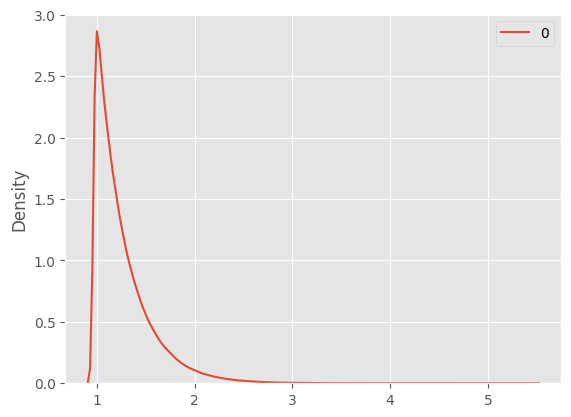

In [112]:
kdeplot(us)

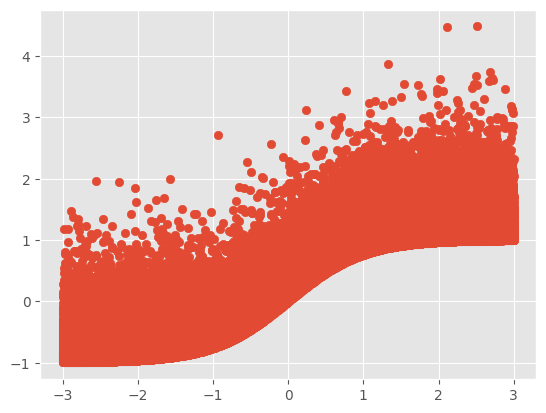

In [4]:
plt.scatter(ys, us)

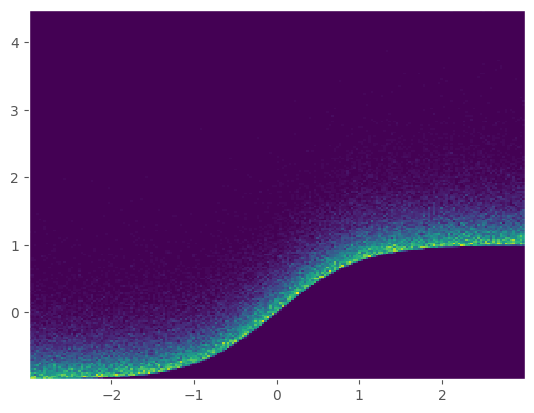

In [5]:
plt.hist2d(ys.squeeze(), us.squeeze(), bins=200);

In [107]:
def exp_reference_sampler(
    key: random.PRNGKey, shape: tuple[int, int]
):
    samples = 0.3 * (random.exponential(key=key, shape=shape))
    return samples

@vmap
def sigmoid_interpolant(t: jnp.array, x1: jnp.array, x0: jnp.array):
    return (1 - sigmoid(t)) * x0 + sigmoid(t) * x1

def sigmoid(t: float) -> float:
    return jax.nn.sigmoid(25 * (t - 0.35))

sigmoid_dot = vmap(grad(sigmoid))

@vmap
def sigmoid_interpolant_der(t: jnp.array, x1: jnp.array, x0: jnp.array):
    return sigmoid_dot(t) * (x1 - x0)

@vmap
def hsu_interpolant(t: jnp.array, x1: jnp.array, x0: jnp.array):
    s = (t - 1) * (t - 1)
    return s * x0 + (1 - s) * x1

@vmap
def hsu_interpolant_der(t, x1, x0):
    return (2 * t - 2) * x0 + (-2 * t + 2) * x1


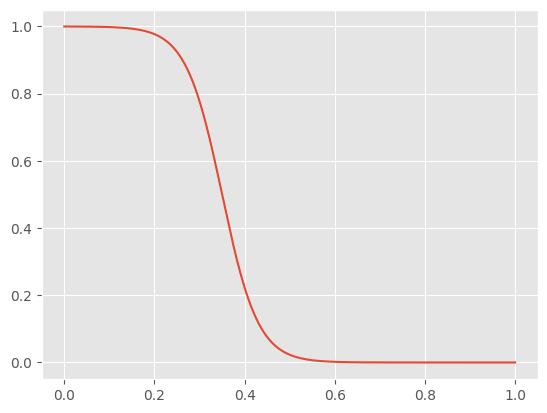

In [108]:
ts = jnp.linspace(0, 1, num=10000)
plt.plot(ts, sigmoid_interpolant(ts, jnp.zeros(10000), jnp.ones(10000)))

In [109]:
sigmoid_interpolant(ts, jnp.zeros(10000), jnp.ones(10000))

Array([9.9984157e-01, 9.9984115e-01, 9.9984080e-01, ..., 1.1920929e-07,
       1.1920929e-07, 1.1920929e-07], dtype=float32)

In [110]:
samps2 = np.load("samps_2.npy")

In [191]:
key1 = random.key(2)
epochs = 400
x1_data = data.copy()
train_dim = 100000
batch_size = 2048
# batch_size = 1024
# batch_size = hyperparams["batch_size"]
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
# hidden_layer_list = [512] * 6
hidden_layer_list = [256] * 4
# hidden_layer_list = [1024] * 8
target_data = x1_data[:train_dim, :]
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=400,
    decay_steps=steps,
    end_value=1e-5,
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.rmsprop(schedule)
)

interpolant = sigmoid_interpolant
interpolant_der = sigmoid_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=exp_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
    # reference_sampler_args=reference_sampler_args,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  1%|          | 109/19600 [00:01<02:20, 138.63it/s]

step = 0, train_loss = 0.010676410980522633


 52%|█████▏    | 10161/19600 [00:09<00:07, 1183.36it/s]

step = 10000, train_loss = -2.9044299125671387


100%|██████████| 19600/19600 [00:17<00:00, 1095.32it/s]

step = 19599, train_loss = -2.9700634479522705


In [192]:
cond_vals = 2
nsamples = 100000
solver_args = {"solver": diffrax.Dopri5(), "max_steps": 50000, "stepsize_controller": diffrax.PIDController(rtol=1e-4, atol=1e-6)}
cond_samples = trainer.conditional_sample(
    cond_values=cond_vals,
    nsamples=nsamples,
    u0_cond=None,
    solver_args=solver_args,
)

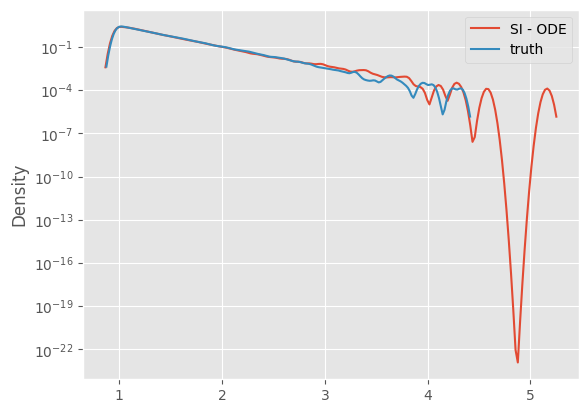

In [193]:
kdeplot(cond_samples[:, 1], label="SI - ODE")
# kdeplot(mcmc_samps2[0].squeeze(), label="MCMC")
kdeplot(samps2.squeeze(), label="truth")
plt.legend()
plt.yscale('log')

In [194]:
wasserstein_1d(np.asarray(cond_samples[:, 1]), samps2.squeeze(), p=2)

np.float64(0.0009144661389771896)

In [ ]:
ys = -3.0 * np.ones((100000, 1))
us = np.tanh(ys) + np.random.gamma(shape=1.0, scale=0.3, size=(100000, 1))
data = np.hstack([ys, us])
np.save("samps_3.npy", us)

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from seaborn import kdeplot
plt.style.use("ggplot")

In [262]:
si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_2/run_{i:02d}/nn_conv_wd_{i}.npy")
wd_ode = np.mean(si_array, axis=0)

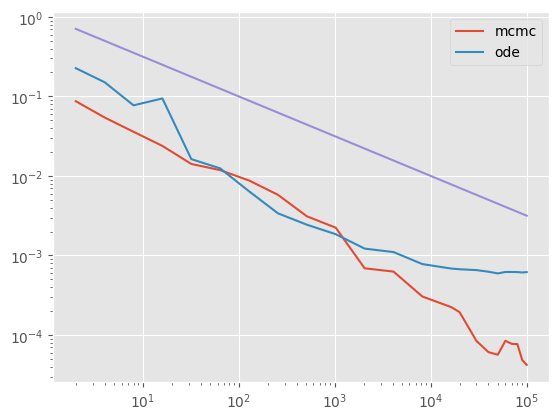

In [ ]:
wd_mcmc = np.load("mcmc_results_2/avg_wd_mcmc.npy")
sample_nos = np.load("sample_no_list.npy")
plt.plot(sample_nos, wd_mcmc, label="mcmc")
plt.plot(sample_nos, wd_ode, label="ode")
plt.xscale("log")
plt.yscale("log")
plt.legend()

In [265]:
wd_ode

array([0.22664682, 0.15077942, 0.07725225, 0.09428134, 0.01626834,
       0.01244831, 0.0064028 , 0.00338618, 0.00243567, 0.00184939,
       0.00121909, 0.00110292, 0.0007784 , 0.00068397, 0.00067051,
       0.00065408, 0.00062401, 0.00059438, 0.00061946, 0.00061937,
       0.00061773, 0.00061045, 0.00061736])

In [273]:
(wd_ode * base_wd)[-1]

np.float64(0.0013145568431204887)

In [7]:
mcmc_samps2 = np.load("mcmc_results_2/mcmc_samps.npy")
samps2 = np.load("samps_2.npy")

In [8]:
samps2.shape

(100000, 1)

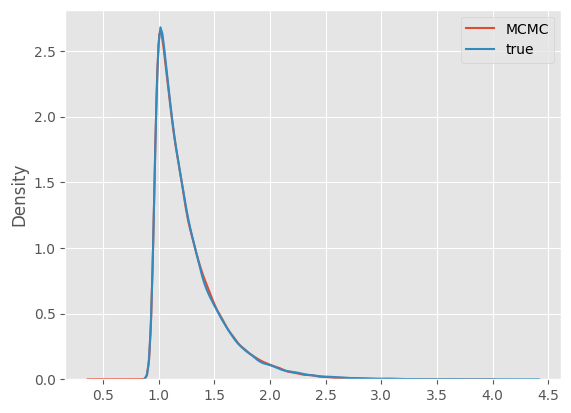

In [18]:
kdeplot(np.vstack(mcmc_samps2[9]).squeeze(), label="MCMC")
kdeplot(samps2.squeeze(), label="true")
plt.legend()

In [24]:
mcmc_samps2[2]

array([[1.23302841],
       [1.23302841],
       [1.19346809],
       ...,
       [1.20813835],
       [1.20813835],
       [1.20813835]], shape=(100000, 1))

In [61]:
from ot.lp import wasserstein_1d as wd
from tqdm.auto import tqdm
no_trials = 10
sample_no_list = sample_nos
mcmc_samps = mcmc_samps2.copy()
wd_array = np.zeros((no_trials, len(sample_no_list)))
for j in tqdm(range(no_trials)):
    for i, sample_no in enumerate(sample_no_list):
        subsamps = mcmc_samps[j, :, :]
        subsamps = subsamps[:sample_no, :]
        wd1 = wd(
            subsamps.reshape(-1),
            samps2.reshape(-1),
            p=2
        )
        wd_array[j, i] = wd1

100%|██████████| 10/10 [00:02<00:00,  3.70it/s]


In [62]:
wd_array

array([[1.80818821e-01, 8.64372774e-02, 3.47308019e-02, 2.83418508e-02,
        3.22102530e-02, 3.45670732e-02, 1.83900528e-02, 3.24207475e-03,
        2.79667422e-03, 2.79707319e-03, 4.61417948e-04, 3.83252350e-04,
        4.83289047e-04, 5.33750607e-04, 2.17664506e-04, 1.36298135e-04,
        4.35123303e-05, 3.90029246e-05, 3.21980995e-05, 8.81350369e-05,
        1.25807776e-04, 7.74574301e-05, 6.22126386e-05],
       [1.76186702e-01, 1.41068398e-01, 1.19177962e-01, 5.72408726e-02,
        1.72381066e-02, 8.12607696e-03, 7.63507955e-03, 1.07528101e-02,
        3.10577072e-03, 1.43208655e-03, 7.79176519e-04, 1.04122810e-03,
        4.10852188e-04, 1.99884574e-04, 1.44716788e-04, 1.12911107e-04,
        2.60440434e-04, 4.85482694e-05, 4.33357163e-05, 3.15585000e-05,
        1.90997449e-05, 2.16637948e-05, 2.13279725e-05],
       [9.10182606e-02, 8.39413577e-02, 8.45898615e-02, 3.11164444e-02,
        1.12627281e-02, 6.37746813e-02, 1.90522301e-02, 6.67226275e-03,
        1.72520249e-03

In [63]:
np.mean(wd_array / base_wd, axis=0)

array([8.70088690e-02, 5.43116454e-02, 3.58988155e-02, 2.38513188e-02,
       1.41456846e-02, 1.18289593e-02, 8.76075045e-03, 5.78610911e-03,
       3.10671747e-03, 2.23377358e-03, 6.88983413e-04, 6.26402026e-04,
       3.04290737e-04, 2.23708803e-04, 1.93518516e-04, 8.38888997e-05,
       6.07778857e-05, 5.63876095e-05, 8.44884450e-05, 7.71601251e-05,
       7.67417315e-05, 4.82164664e-05, 4.20383829e-05])

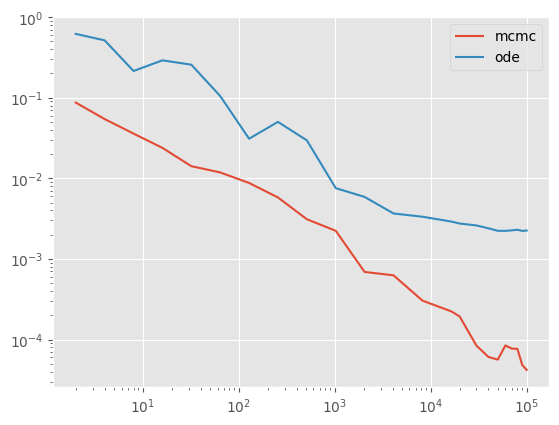

In [64]:
plt.plot(sample_nos, np.mean(wd_array / base_wd, axis=0), label="mcmc")
plt.plot(sample_nos, wd_ode, label="ode")
plt.xscale("log")
plt.yscale("log")
plt.legend()

In [12]:
mcmc_samps2[0][np.where(mcmc_samps2[0] < 0.85)[0]]

array([[-2.54093885],
       [-2.54093885],
       [-2.54093885],
       ...,
       [-2.54093885],
       [-2.54093885],
       [-2.54093885]], shape=(100000, 1))

In [23]:
np.sort(mcmc_samps2[1].squeeze())

array([-0.15122318, -0.15122318, -0.15122318, ...,  3.6256063 ,
        3.65382051,  3.69635677], shape=(100000,))